# Market-Implied Credit Risk from Bond Spreads

## 1. Introduction

Credit spreads are widely monitored in fixed income markets,
but what do they actually imply about default risk?

This notebook explores how credit spreads can be translated
into market-implied default risk and how this risk co-moves
with macro conditions.

The goal is not to build a full pricing model,
but to analyze what credit markets are implying about risk.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from creditlab.data import fetch_fred_series

plt.rcParams["figure.figsize"] = (12, 5)

ecba773410df853751fba1a77d629827


## 2. Data

We use US corporate bond spreads from FRED.

Credit spreads represent the extra yield investors demand
to hold corporate bonds instead of Treasuries.

They reflect:
- expected default losses  
- liquidity risk  
- risk premia

In [ ]:
bbb = fetch_fred_series("BAMLC0A4CBBB").rename(columns={"value": "bbb_oas_pct"})
ig = fetch_fred_series("BAMLC0A0CM").rename(columns={"value": "ig_oas_pct"})

df = bbb.merge(ig, on="date", how="inner").copy()

df.shape, df["date"].min(), df["date"].max()

((7602, 3), Timestamp('1996-12-31 00:00:00'), Timestamp('2026-02-12 00:00:00'))

## Credit spreads visualization

BBB spreads are structurally higher than IG spreads,
reflecting higher perceived credit risk.

Periods of widening spreads often correspond to macro or financial stress.

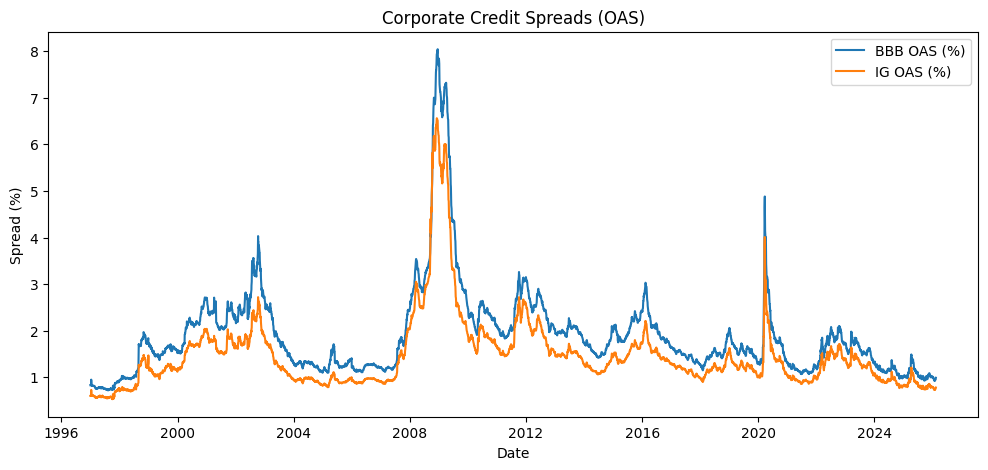

In [79]:
plt.plot(df["date"], df["bbb_oas_pct"], label="BBB OAS (%)")
plt.plot(df["date"], df["ig_oas_pct"], label="IG OAS (%)")

plt.title("Corporate Credit Spreads (OAS)")
plt.xlabel("Date")
plt.ylabel("Spread (%)")
plt.legend()
plt.show()

## 3. From spreads to implied default risk

A simple reduced-form approximation links spreads
to default intensity:

spread ≈ (1 − recovery) × default intensity

So:

default intensity ≈ spread / (1 − recovery)

This provides a first-order measure
of market-implied default risk.

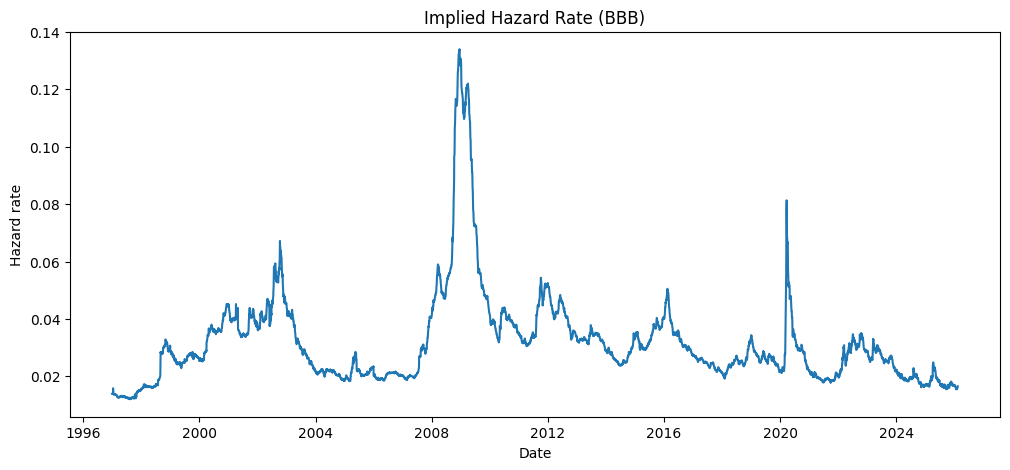

,Maturity (years),Survival probability
0,1.0,0.983635
1,3.0,0.951705
2,5.0,0.920811
3,10.0,0.847894


In [80]:
RECOVERY = 0.40
LGD = 1 - RECOVERY

df["bbb_oas"] = df["bbb_oas_pct"] / 100
df["bbb_hazard"] = df["bbb_oas"] / LGD

plt.plot(df["date"], df["bbb_hazard"])
plt.title("Implied Hazard Rate (BBB)")
plt.xlabel("Date")
plt.ylabel("Hazard rate")
plt.show()

# Survival illustration
T = np.array([1,3,5,10], dtype=float)
lam = float(df["bbb_hazard"].iloc[-1])

survival = np.exp(-lam * T)

pd.DataFrame({
    "Maturity (years)": T,
    "Survival probability": survival
})

## 4. Fair CDS spread intuition

A CDS can be viewed as insurance against default.

The buyer:
- pays a premium  
- receives compensation if default occurs

At a fair price:

total premiums ≈ expected loss

This links CDS spreads to default probabilities.

In [81]:
def fair_cds_spread_simple(hazard, recovery, maturity):
    """
    Simple fair CDS spread approximation.
    
    hazard: default intensity (annual)
    recovery: recovery rate (e.g. 0.40)
    maturity: in years
    """
    
    # cumulative default probability
    PD = 1 - np.exp(-hazard * maturity)
    
    # fair spread
    fair_spread = (1 - recovery) * PD / maturity
    
    return fair_spread

In [82]:
hazard = df["bbb_hazard"].iloc[-1]

fair_spread = fair_cds_spread_simple(
    hazard=hazard,
    recovery=0.40,
    maturity=5
)

fair_spread

np.float64(0.009502627457183456)

In [83]:
observed_spread = df["bbb_oas"].iloc[-1]

print("Observed spread:", observed_spread)
print("Fair CDS spread:", fair_spread)


comparison = pd.DataFrame({
    "Metric": ["Observed OAS (decimal)", "Fair CDS spread (decimal)"],
    "Value": [observed_spread, fair_spread],
})
comparison["bps"] = comparison["Value"] * 10000
comparison

Observed spread: 0.009899999999999999
Fair CDS spread: 0.009502627457183456


,Metric,Value,bps
0,Observed OAS (decimal),0.009900,99.000000
1,Fair CDS spread (decimal),0.009503,95.026275


## Interpretation

If the observed spread is close to the fair spread,
it suggests consistency with the implied default risk.

If the observed spread is higher,
it may reflect liquidity premia or risk aversion.

If lower,
the market may be pricing lower default risk.

## 5. Macro-credit relationship

Structural credit intuition (Merton, 1974)
suggests that default risk rises when
economic conditions deteriorate.

We test whether changes in rates
co-move with changes in implied default risk.


## Macro–credit relationship: definitions and estimation

We study the link between macro conditions and credit risk using:

- `bbb_hazard(t)`: implied default intensity (annualized), derived from BBB OAS using a reduced-form approximation.
- `rate_2y(t)`: 2-year US Treasury yield (proxy for macro / monetary conditions).

To avoid spurious correlations from levels, we work mainly with **changes**:

- Δhazard(t) = hazard(t) − hazard(t−1)
- Δrate(t) = rate_2y(t) − rate_2y(t−1)

We estimate a simple linear model (OLS):

Δhazard(t) = α + β · Δrate(t) + ε(t)

Interpretation:
- If β < 0, decreases in rates (Δrate < 0) are associated with increases in credit risk (Δhazard > 0).
This is consistent with a stress / flight-to-quality intuition.

This is an empirical association, not a causal identification.

In [ ]:
rates2y = fetch_fred_series("DGS2").rename(columns={"value": "rate_2y_pct"})
rates2y["rate_2y"] = rates2y["rate_2y_pct"] / 100.0

df_macro = df.merge(rates2y[["date", "rate_2y"]], on="date", how="inner").copy()

df_macro[["date", "bbb_hazard", "rate_2y"]].tail()

,date,bbb_hazard,rate_2y
7267,2026-02-05,0.016000,0.0347
7268,2026-02-06,0.016000,0.0350
7269,2026-02-09,0.016000,0.0348
7270,2026-02-10,0.016333,0.0345
7271,2026-02-11,0.016333,0.0352


In [85]:
df_macro = df_macro.sort_values("date").reset_index(drop=True)

df_macro["d_hazard"] = df_macro["bbb_hazard"].diff()
df_macro["d_rate_2y"] = df_macro["rate_2y"].diff()

# Option: also compute standardized changes (z-scores) for comparability
df_macro["d_hazard_z"] = (df_macro["d_hazard"] - df_macro["d_hazard"].mean()) / df_macro["d_hazard"].std()
df_macro["d_rate_2y_z"] = (df_macro["d_rate_2y"] - df_macro["d_rate_2y"].mean()) / df_macro["d_rate_2y"].std()

df_reg = df_macro.dropna(subset=["d_hazard", "d_rate_2y"]).copy()
df_reg[["date","d_hazard","d_rate_2y"]].head()


,date,d_hazard,d_rate_2y
1,1997-01-02,0.000000,0.0009
2,1997-01-03,0.000000,-0.0002
3,1997-01-06,0.000333,0.0002
4,1997-01-07,-0.000167,0.0001
5,1997-01-08,-0.000167,0.0003


In [86]:
def ols_simple(y: np.ndarray, x: np.ndarray):
    """
    OLS for y = a + b x + e
    Returns a, b, t-stat(b), R^2
    """
    y = y.astype(float)
    x = x.astype(float)
    n = len(y)

    X = np.column_stack([np.ones(n), x])  # [1, x]
    beta = np.linalg.inv(X.T @ X) @ (X.T @ y)  # [a, b]
    y_hat = X @ beta
    resid = y - y_hat

    # R^2
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # standard error of b
    k = 2
    sigma2 = ss_res / (n - k)
    cov_beta = sigma2 * np.linalg.inv(X.T @ X)
    se_b = np.sqrt(cov_beta[1, 1])

    t_b = beta[1] / se_b if se_b > 0 else np.nan

    return float(beta[0]), float(beta[1]), float(t_b), float(r2), int(n)

y = df_reg["d_hazard"].to_numpy()
x = df_reg["d_rate_2y"].to_numpy()

a, b, t_b, r2, n = ols_simple(y, x)

result = pd.DataFrame({
    "parameter": ["alpha", "beta (d_rate_2y)", "t-stat(beta)", "R2", "n_obs"],
    "value": [a, b, t_b, r2, n]
})
result

,parameter,value
0,alpha,-3.106657e-07
1,beta (d_rate_2y),-2.016462e-01
2,t-stat(beta),-1.935259e+01
3,R2,4.899870e-02
4,n_obs,7.271000e+03


### Interpretation of β

β measures how much the implied credit risk (Δhazard) moves when rates move (Δrate).

- If β is negative:
  rate decreases (Δrate < 0) tend to coincide with hazard increases (Δhazard > 0).
  This matches a “risk-off / stress” intuition.

R² is not expected to be high on daily data; the point is to quantify direction and magnitude.


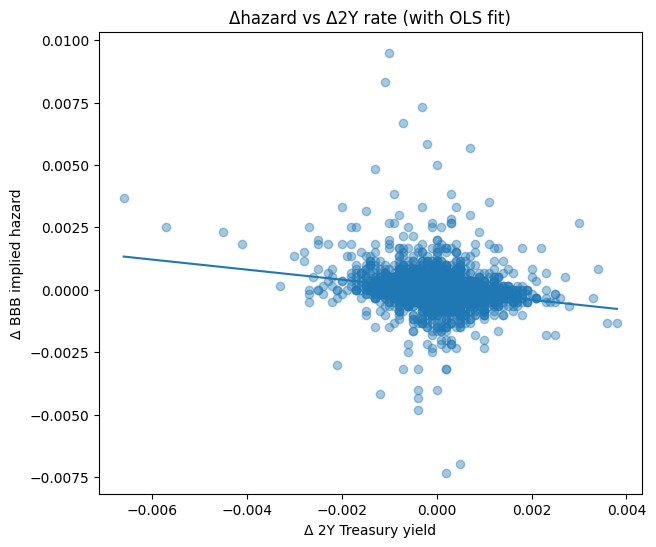

In [87]:
plt.figure(figsize=(7,6))
plt.scatter(df_reg["d_rate_2y"], df_reg["d_hazard"], alpha=0.4)

# regression line: y = a + b x
x_line = np.linspace(df_reg["d_rate_2y"].min(), df_reg["d_rate_2y"].max(), 200)
y_line = a + b * x_line
plt.plot(x_line, y_line)

plt.title("Δhazard vs Δ2Y rate (with OLS fit)")
plt.xlabel("Δ 2Y Treasury yield")
plt.ylabel("Δ BBB implied hazard")
plt.show()

## Rolling regression (time-varying relationship)

To check whether the macro–credit relationship is stable,
we estimate β on a rolling window (ex 250 trading days ≈ 1 year).

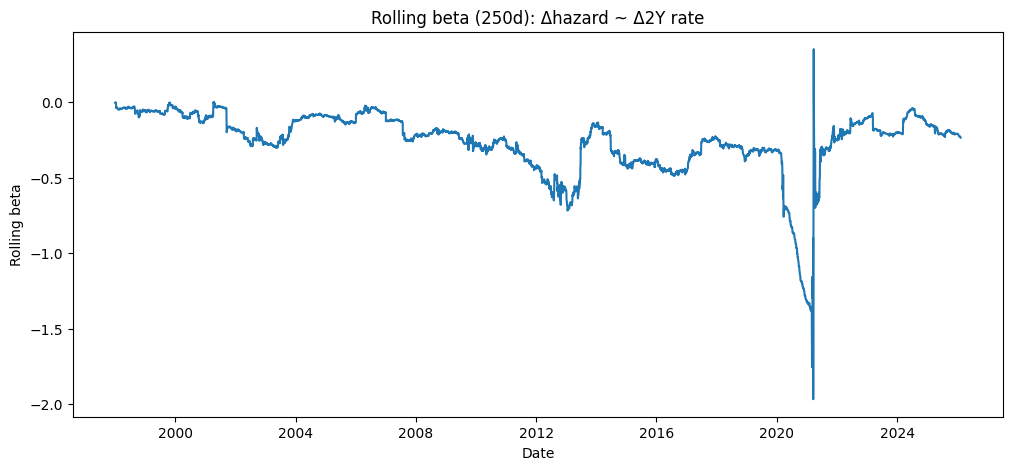

In [88]:
window = 250
betas = []
dates = []

x_all = df_reg["d_rate_2y"].to_numpy()
y_all = df_reg["d_hazard"].to_numpy()
date_all = df_reg["date"].to_numpy()

for i in range(window, len(df_reg)):
    y_w = y_all[i-window:i]
    x_w = x_all[i-window:i]
    a_w, b_w, t_w, r2_w, n_w = ols_simple(y_w, x_w)
    betas.append(b_w)
    dates.append(date_all[i])

roll = pd.DataFrame({"date": pd.to_datetime(dates), "beta_roll_250d": betas})

plt.figure(figsize=(12,5))
plt.plot(roll["date"], roll["beta_roll_250d"])
plt.title("Rolling beta (250d): Δhazard ~ Δ2Y rate")
plt.xlabel("Date")
plt.ylabel("Rolling beta")
plt.show()

## 6. Relative value and simple backtest

If observed spreads deviate strongly
from model-implied fair value,
this may reflect market stress.

We construct a z-score
and check whether large deviations
tend to mean-revert.

In [89]:
df["fair_spread_5Y"] = fair_cds_spread_simple(
    hazard=df["bbb_hazard"],
    recovery=0.40,
    maturity=5
)

In [90]:
# difference between observed and fair spread
df["spread_diff"] = df["bbb_oas"] - df["fair_spread_5Y"]

In [91]:
df["zscore"] = (df["spread_diff"] - df["spread_diff"].mean()) / df["spread_diff"].std()

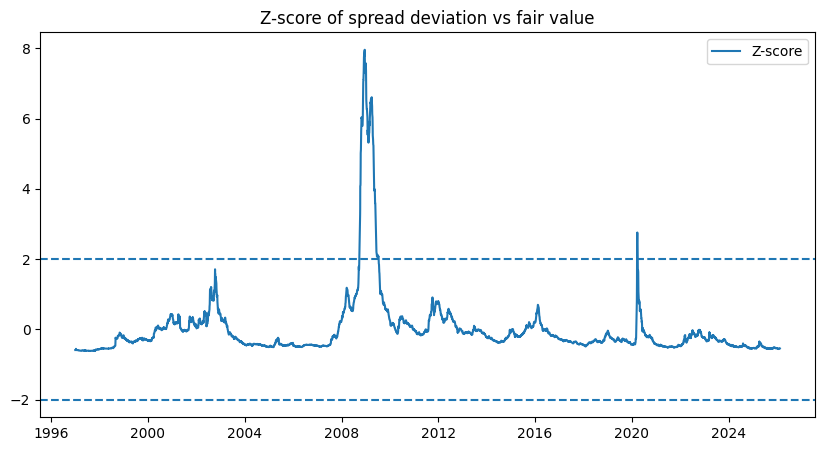

In [92]:
plt.figure(figsize=(10,5))

plt.plot(df["date"], df["zscore"], label="Z-score")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.title("Z-score of spread deviation vs fair value")
plt.legend()
plt.show()

In [93]:
df["future_spread_change"] = (
    df["bbb_oas"].shift(-60) - df["bbb_oas"]
)

In [94]:
df[["zscore","future_spread_change"]].corr()

,zscore,future_spread_change
zscore,1.000000,-0.297975
future_spread_change,-0.297975,1.000000


In [95]:
high_signal = df[df["zscore"] > 2]["future_spread_change"].mean()
low_signal  = df[df["zscore"] < -2]["future_spread_change"].mean()

print("Avg future change when z-score > 2:", high_signal)
print("Avg future change when z-score < -2:", low_signal)

Avg future change when z-score > 2: -0.009872769953051645
Avg future change when z-score < -2: nan


Large positive z-scores often coincide with stressed markets.

If future spread changes are negative on average
after high z-scores,
this suggests mean-reversion.

This is not a trading strategy,
but a simple signal check.

## 7. Conclusion

This notebook explored how corporate bond spreads can be
translated into simple measures of market-implied credit risk.

Using a reduced-form intuition, we mapped spreads to
implied default intensities and survival probabilities,
and derived a simple fair CDS spread approximation.

Several insights emerge:

• Credit spreads contain information about market-implied default risk  
• Implied hazard rates vary over time and react to market conditions  
• Simple CDS intuition already links spreads to expected loss  
• Deviations between observed and fair spreads can be interpreted
  as relative value signals  
• Extreme deviations often coincide with stressed market periods
  and may partially mean-revert  

We also examined a basic macro-credit relationship,
showing that changes in interest rates tend to co-move
with changes in implied credit risk.

This analysis remains intentionally simple.
It does not attempt to build a full CDS pricing framework.

Key limitations include:

• Constant recovery assumption  
• OAS used as a proxy for CDS spreads  
• No term structure of hazard rates  
• No discount curve modelling  
• No separation of liquidity vs credit premia  

Overall, this notebook is meant as an exploratory,
data-driven view of what credit markets may be implying
about default risk.

It illustrates how relatively simple tools
can already provide useful intuition
for credit market analysis.